# Parameters

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import sys
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Agora pode importar o config
from notebooks.config import config

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterSpectralModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.SHAPClassifierModule import *

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = config["datapath"]
COVID_TRAIN_DATA_FILE = config["covid_train_data_file"]
COVID_TEST_DATA_FILE = config["covid_test_data_file"]
FUTURE_DATA_FILE = config["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = config["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = config["figsize_future_heatmap"]
IMAGES_SAVE_PATH = config["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

shap.initjs()


## Get Top features

In [4]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [5]:
helper = ShapHelperClassifier(
    covid_train.drop(columns=["subject_id", "hadm_id"]),
    covid_test.drop(columns=["subject_id", "hadm_id"]),
    "died",
)
helper.removeFeatures(features2remove)

Train size: 2348
Test size: 1007


In [6]:
param = {
    "learning_rate": 0.03194788423314631,
    "n_estimators": 855,
    "gamma": 0.15986032691615765,
    "reg_alpha": 0.7169178389895312,
    "reg_lambda": 0.5826947399857607,
    "scale_pos_weight": 12,
}

Accuracy:  0.7865
Precision: 0.5613
Recall:    0.6877
F1 Score:  0.6181


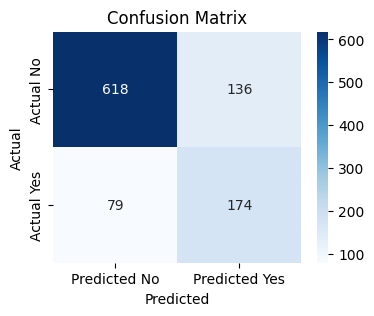

In [7]:
helper.singleModel(param, model_name="xgboost")
helper.printMetrics()
helper.showConfMatrix()

In [8]:
helper.shapConfig()

 95%|=================== | 960/1007 [00:17<00:00]       

In [9]:
features = helper.getTopFeatures(20)

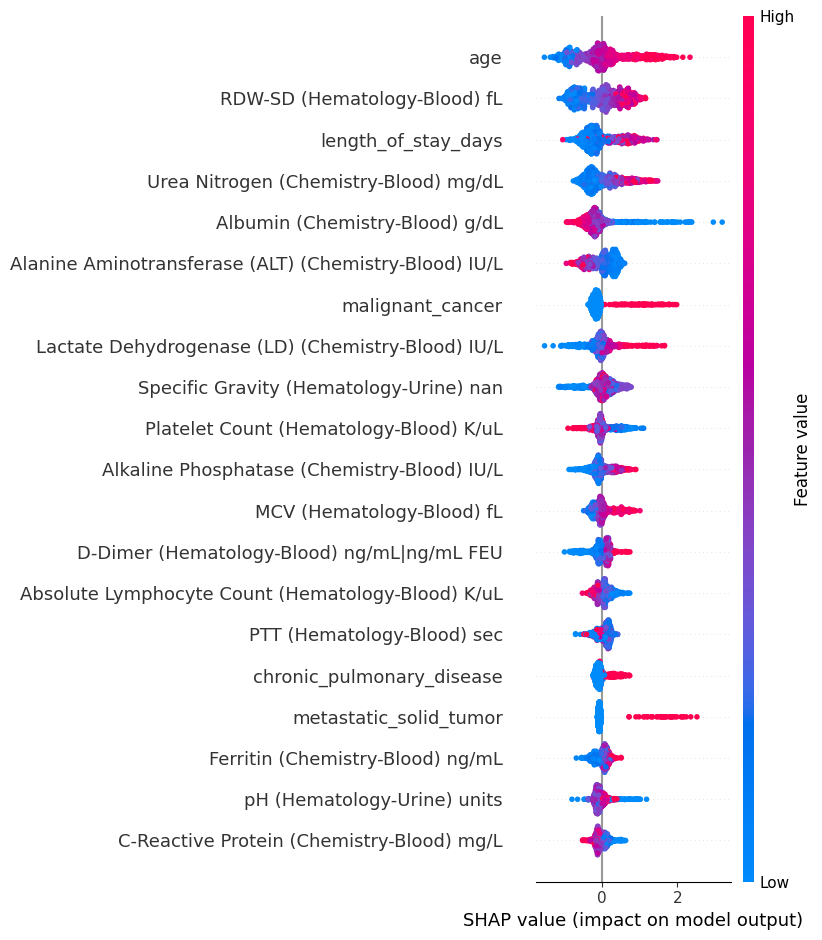

In [10]:
helper.showSummaryShap(verbose=2)

In [11]:
features

['age',
 'RDW-SD_Hematology_Blood_fL',
 'length_of_stay_days',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Albumin_Chemistry_Blood_g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'malignant_cancer',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'Specific Gravity_Hematology_Urine_nan',
 'Platelet Count_Hematology_Blood_K/uL',
 'Alkaline Phosphatase_Chemistry_Blood_IU/L',
 'MCV_Hematology_Blood_fL',
 'D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
 'Absolute Lymphocyte Count_Hematology_Blood_K/uL',
 'PTT_Hematology_Blood_sec',
 'chronic_pulmonary_disease',
 'metastatic_solid_tumor',
 'Ferritin_Chemistry_Blood_ng/mL',
 'pH_Hematology_Urine_units',
 'C-Reactive Protein_Chemistry_Blood_mg/L']

## Setup Hierarchical Clustering

In [12]:
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [13]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
featuresNotConsidered = [x for x in data_covid.columns.tolist() if x not in features]

In [15]:
helper = cluster.SpectralClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for Spectral clustering

In [16]:
param = {
    "affinity": ["rbf", "nearest_neighbors"],
    "gamma": {"min": 1e-4, "max": 1e-2},
    "n_neighbors": {"min": 1, "max": 100},
    "n_clusters": {"min": 2, "max": 5},
}

In [17]:
os.environ['PYTHONWARNINGS'] = 'ignore'
disco_df, disco_param, disco_best = helper.optunaGridSearch(
    suffix="death",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 22:23:05,421] A new study created in RDB with name: Optuna Study Spectral Clustering Death DISCO 0
[I 2026-01-17 22:23:06,985] Trial 0 finished with value: 0.1334167822342129 and parameters: {'affinity': 'rbf', 'gamma': 0.0004124608403338774, 'n_clusters': 3}. Best is trial 0 with value: 0.1334167822342129.
[I 2026-01-17 22:23:08,454] Trial 1 finished with value: 0.1341189066554942 and parameters: {'affinity': 'rbf', 'gamma': 0.00036874998911108587, 'n_clusters': 3}. Best is trial 1 with value: 0.1341189066554942.
[I 2026-01-17 22:23:09,825] Trial 2 finished with value: 0.22870477092070218 and parameters: {'affinity': 'rbf', 'gamma': 0.0005699148154159728, 'n_clusters': 2}. Best is trial 2 with value: 0.22870477092070218.
[I 2026-01-17 22:23:13,196] Trial 3 finished with value: 0.026617390309117042 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 19, 'n_clusters': 3}. Best is trial 2 with value: 0.22870477092070218.
[I 2026-01-17 22:23:16,492] Trial 4 fini


Best parameters: {'affinity': 'rbf', 'gamma': 0.0001028252458301356, 'n_clusters': 2}
Best DISCO score: 0.2784501147068326



In [18]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
    suffix="death",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 22:29:24,069] A new study created in RDB with name: Optuna Study Spectral Clustering Death DBCV 0
[I 2026-01-17 22:29:30,046] Trial 0 finished with value: -0.9934758031300748 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 36, 'n_clusters': 4}. Best is trial 0 with value: -0.9934758031300748.
[I 2026-01-17 22:29:33,661] Trial 1 finished with value: -0.995411490501644 and parameters: {'affinity': 'rbf', 'gamma': 0.0018532899468702052, 'n_clusters': 4}. Best is trial 0 with value: -0.9934758031300748.
[I 2026-01-17 22:29:38,717] Trial 2 finished with value: -0.993610679467597 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 41, 'n_clusters': 4}. Best is trial 0 with value: -0.9934758031300748.
[I 2026-01-17 22:29:43,452] Trial 3 finished with value: -0.993237115928545 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 45, 'n_clusters': 5}. Best is trial 3 with value: -0.993237115928545.
[I 2026-01-17 22:29:48,622] Trial 4 finis


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 12, 'n_clusters': 5}
Best DBCV score: -0.8577165079066355



In [19]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
    suffix="death",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 22:48:27,256] A new study created in RDB with name: Optuna Study Spectral Clustering Death DSI 0
[I 2026-01-17 22:48:29,195] Trial 0 finished with value: 0.118 and parameters: {'affinity': 'rbf', 'gamma': 0.0008271571680770138, 'n_clusters': 4}. Best is trial 0 with value: 0.118.
[I 2026-01-17 22:48:31,123] Trial 1 finished with value: 0.172 and parameters: {'affinity': 'rbf', 'gamma': 0.000452493493793977, 'n_clusters': 5}. Best is trial 1 with value: 0.172.
[I 2026-01-17 22:48:31,888] Trial 2 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0012151804773663122, 'n_clusters': 2}. Best is trial 1 with value: 0.172.
[I 2026-01-17 22:48:34,611] Trial 3 finished with value: -2.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 29, 'n_clusters': 2}. Best is trial 1 with value: 0.172.
[I 2026-01-17 22:48:38,223] Trial 4 finished with value: 0.093 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 89, 'n_clusters': 5}. Best 


Best parameters: {'affinity': 'rbf', 'gamma': 0.0004010465616092783, 'n_clusters': 3}
Best DSI score: 0.267



In [20]:
os.environ['PYTHONWARNINGS'] = 'ignore'
silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
    suffix="death",
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 22:56:05,057] A new study created in RDB with name: Optuna Study Spectral Clustering Death SILHOUETTE 0
[I 2026-01-17 22:56:07,773] Trial 0 finished with value: -0.126 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 89, 'n_clusters': 5}. Best is trial 0 with value: -0.126.
[I 2026-01-17 22:56:10,412] Trial 1 finished with value: -0.126 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 89, 'n_clusters': 5}. Best is trial 0 with value: -0.126.
[I 2026-01-17 22:56:11,165] Trial 2 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.007572382051931117, 'n_clusters': 3}. Best is trial 0 with value: -0.126.
[I 2026-01-17 22:56:13,907] Trial 3 finished with value: -0.022 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 87, 'n_clusters': 3}. Best is trial 3 with value: -0.022.
[I 2026-01-17 22:56:14,963] Trial 4 finished with value: 0.125 and parameters: {'affinity': 'rbf', 'gamma': 0.0009376944294791971, 'n_clus


Best parameters: {'affinity': 'rbf', 'gamma': 0.00010553261665113892, 'n_clusters': 2}
Best SILHOUETTE score: 0.291



In [21]:
helper.clustering(
    n_clusters=disco_param["n_clusters"],
    affinity=disco_param["affinity"],
    n_neighbors=disco_param.get("n_neighbors", 10),
    gamma=disco_param.get("gamma", 1e-3)
)
helper.getMetrics()

{'silhouette': 0.291,
 'dbcv': -0.9910683011240341,
 'dsi': np.float64(0.217),
 'disco': np.float64(0.2784501147068326)}

In [22]:
helper.clustering(
    n_clusters=dbcv_param["n_clusters"],
    affinity=dbcv_param["affinity"],
    n_neighbors=dbcv_param.get("n_neighbors", 10),
    gamma=dbcv_param.get("gamma", 1e-3)
)
helper.getMetrics()

{'silhouette': -0.013,
 'dbcv': -0.8577165079066355,
 'dsi': np.float64(0.075),
 'disco': np.float64(0.023265859576337845)}

In [23]:
helper.clustering(
    n_clusters=dsi_param["n_clusters"],
    affinity=dsi_param["affinity"],
    n_neighbors=dsi_param.get("n_neighbors", 10),
    gamma=dsi_param.get("gamma", 1e-3)
)
helper.getMetrics()

{'silhouette': 0.164,
 'dbcv': -0.9958486455454107,
 'dsi': np.float64(0.267),
 'disco': np.float64(0.1360860000144677)}

In [24]:
helper.clustering(
    n_clusters=silhouette_param["n_clusters"],
    affinity=silhouette_param["affinity"],
    n_neighbors=silhouette_param.get("n_neighbors", 10),
    gamma=silhouette_param.get("gamma", 1e-3)
)
helper.getMetrics()

{'silhouette': 0.291,
 'dbcv': -0.9910683011240341,
 'dsi': np.float64(0.217),
 'disco': np.float64(0.2784501147068326)}

In [26]:
best_param = silhouette_param
best_param

{'affinity': 'rbf', 'gamma': 0.00010553261665113892, 'n_clusters': 2}

### Best

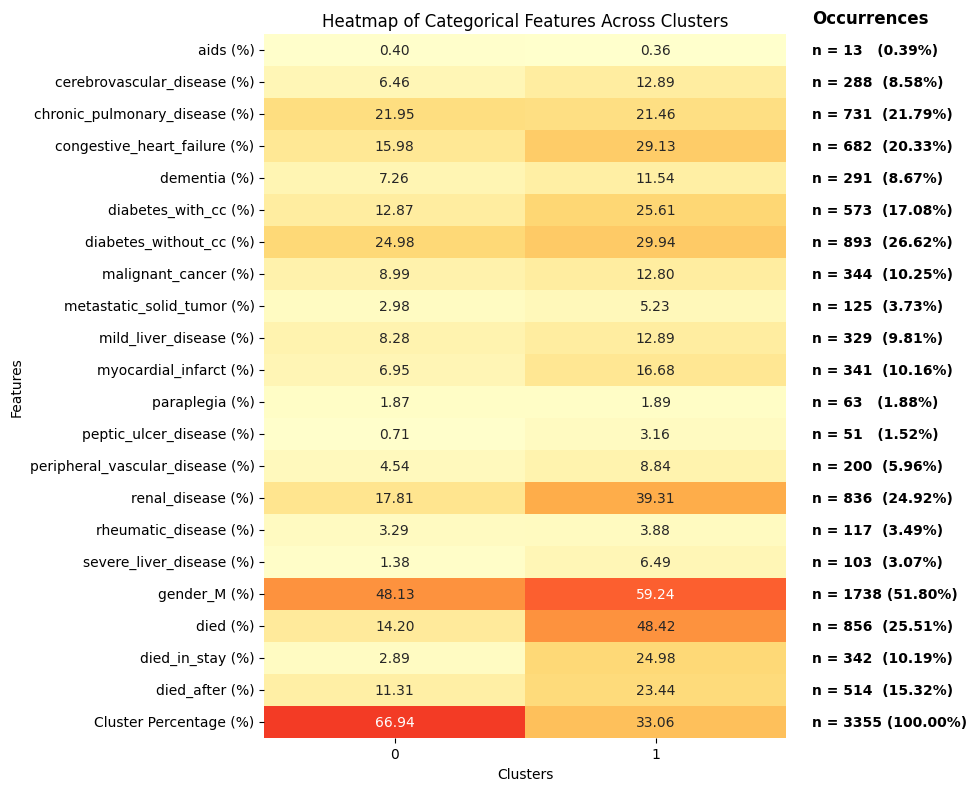

In [27]:
helper.clustering(
    n_clusters=best_param["n_clusters"],
    affinity=best_param["affinity"],
    n_neighbors=best_param.get("n_neighbors", 10),
    gamma=best_param.get("gamma", 1e-3)
)
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "spectral-death-categorical"
)

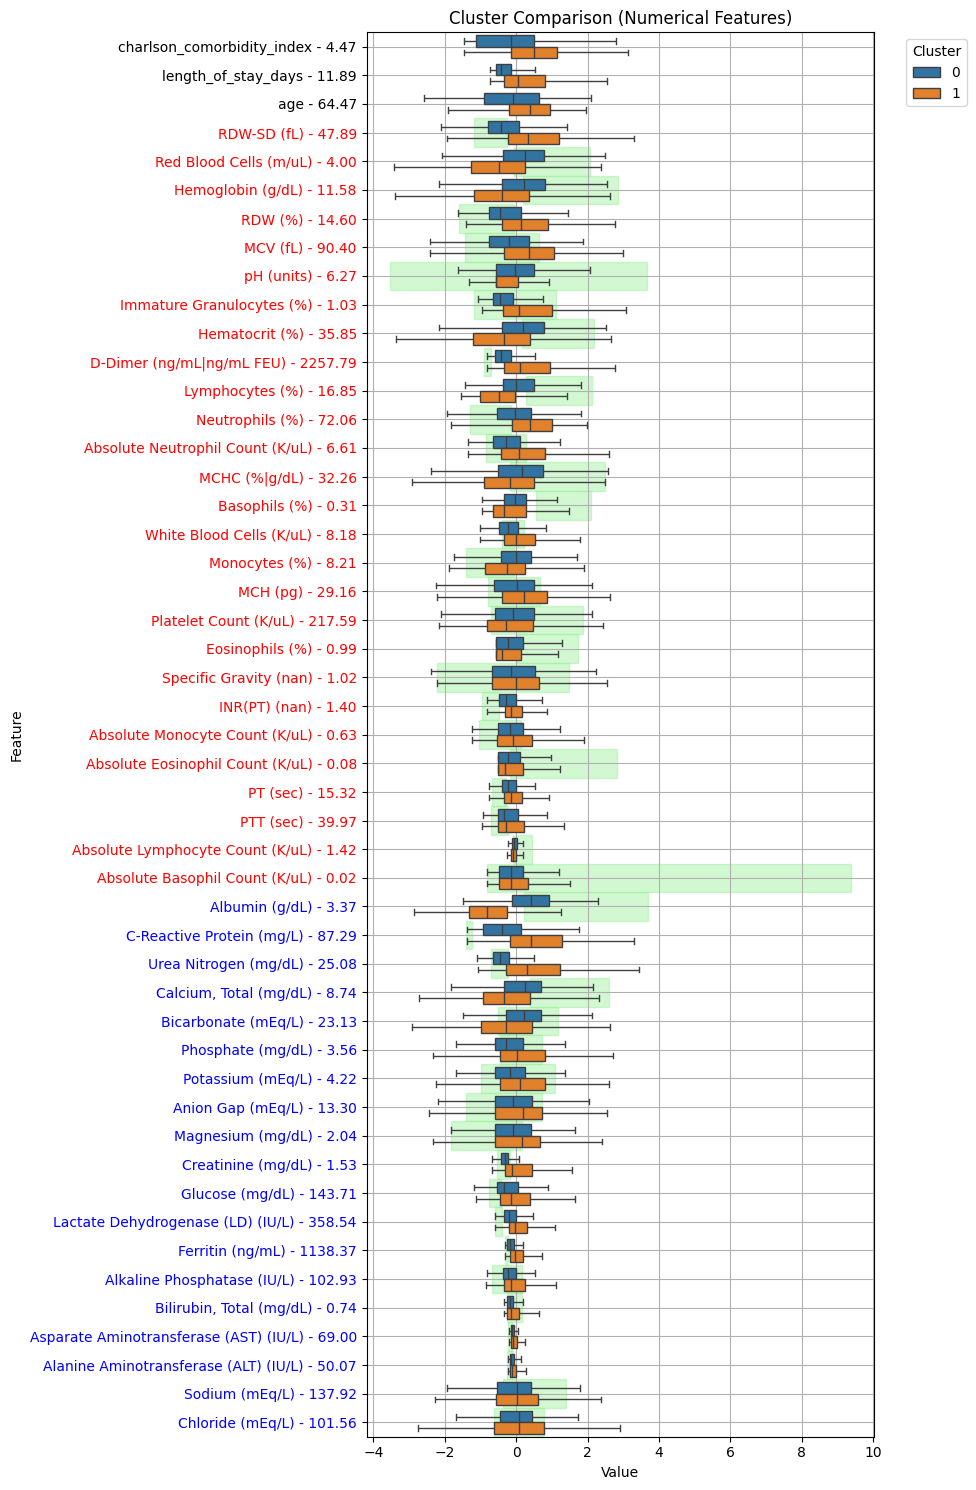

[]

In [28]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    minimumClusterSize=5,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "spectral-death-numerical", verbose=1)

In [29]:
selectedClusters = [0,1]

In [30]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:25<00:00,  3.98it/s]


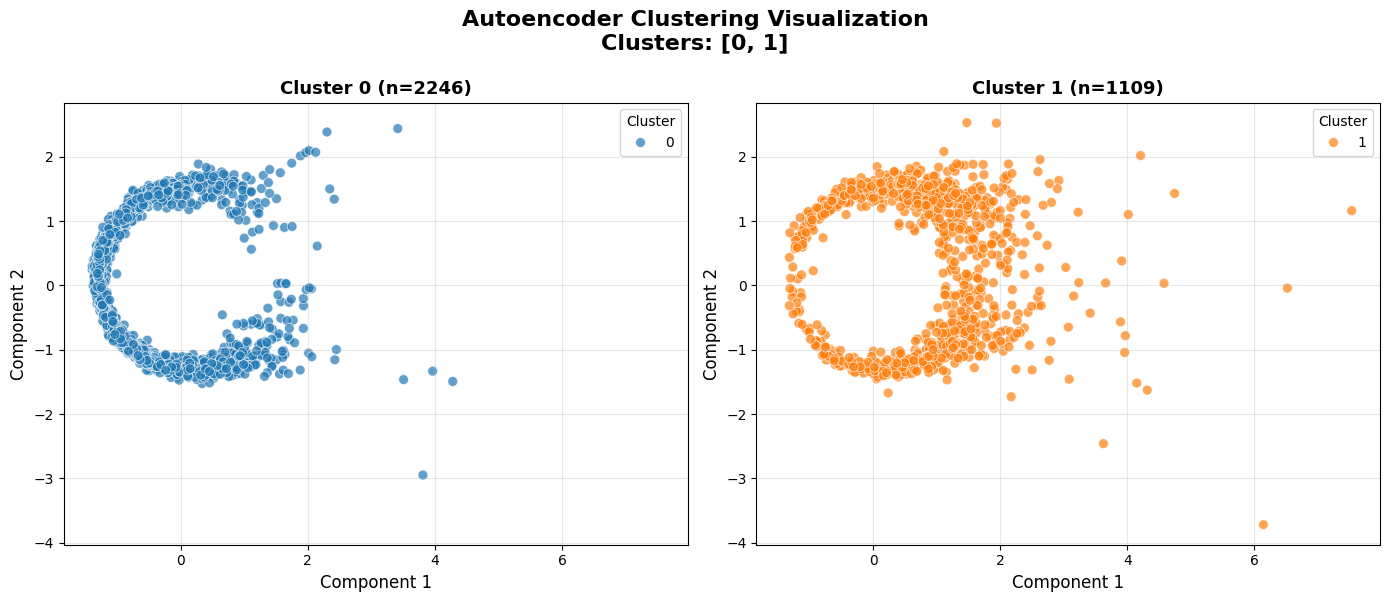

In [31]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "spectral-autoencoder-death")

##### Future data

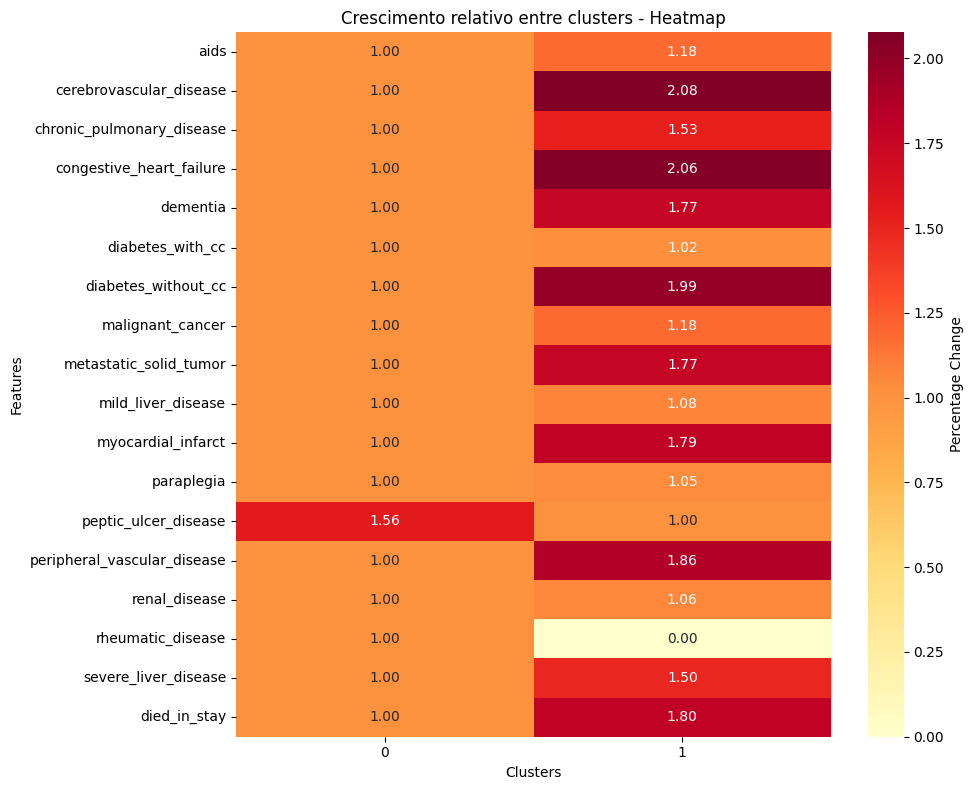

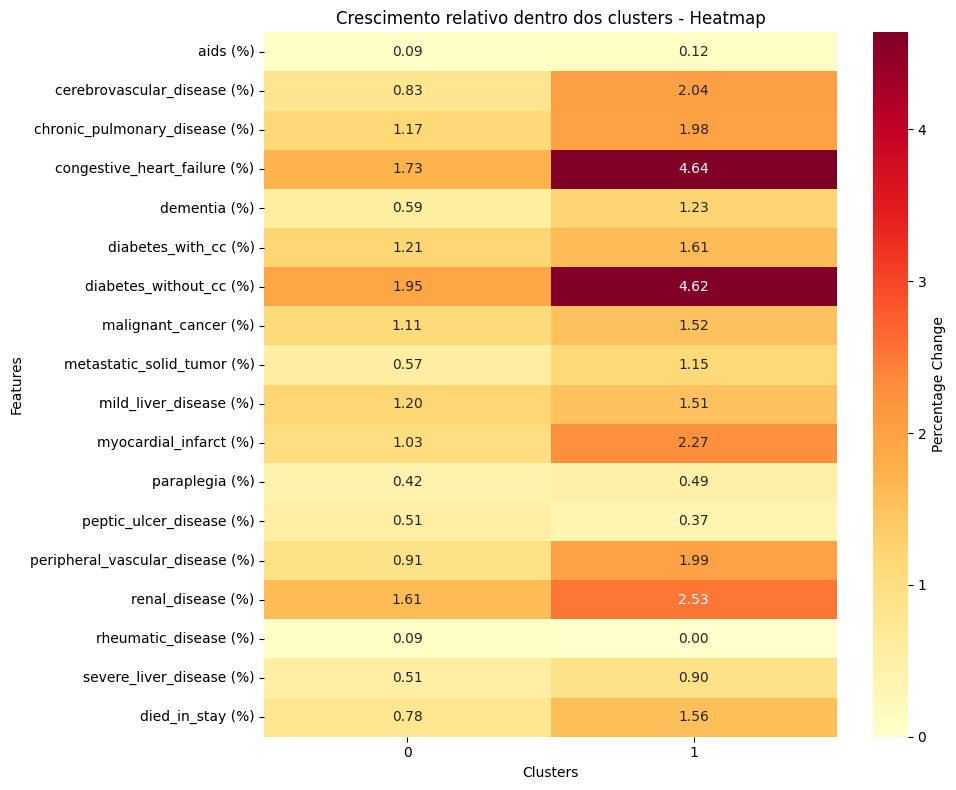

In [32]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "spectral-death-externo", selectedClusters=selectedClusters,
    metric="externo"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "spectral-death-interno", selectedClusters=selectedClusters,
    metric="interno"
)

In [33]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.27,
 'Mean readmission Cluster 1': 2.42,
 'Overall Mean readmission': 2.31}

In [34]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 128.78,
 'Mean days gap Cluster 1': 124.45,
 'Overall Mean days gap': 127.49}

In [35]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.26,
 'Mortality rate Cluster 1': 0.05,
 'Overall Mortality rate': 0.09}

# Add Log

In [36]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Spectral,Shap,Comprehensive,{metrics['disco']},{metrics['dbcv']},{metrics['dsi']},{metrics['silhouette']}\n")